Please upload the ZIP file.


Saving archive (1).zip to archive (1) (1).zip

Uploaded file:
archive (1) (1).zip

ZIP file extracted successfully!

CSV file found:
/content/social_network_dataset/Social_Network_Ads.csv

Dataset loaded successfully!
Dataset shape: (400, 5)

Column names:
['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']

First 5 rows:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Missing values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Features:
['Gender', 'Age', 'EstimatedSalary']

Target: Purchased

X shape: (400, 3)
y shape: (400, 1)

Training samples: 320
Testing samples: 80


RUNNING GRADIENT DESCENT
Iteration    0 | Loss: 0.693147
Iteratio

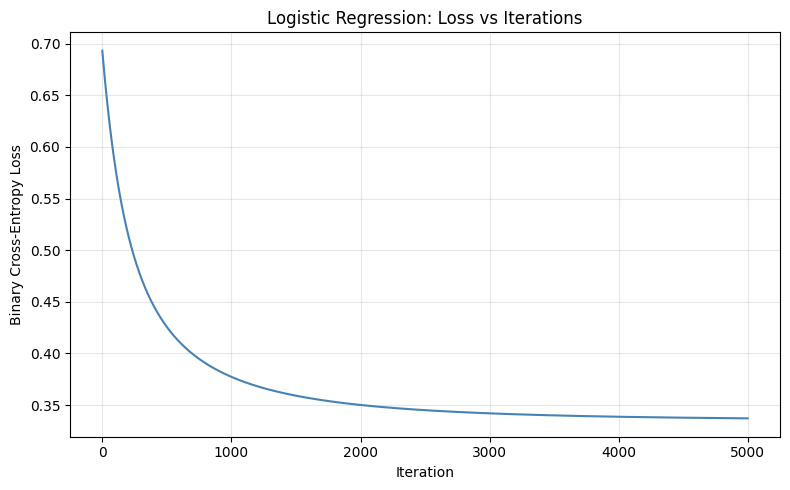

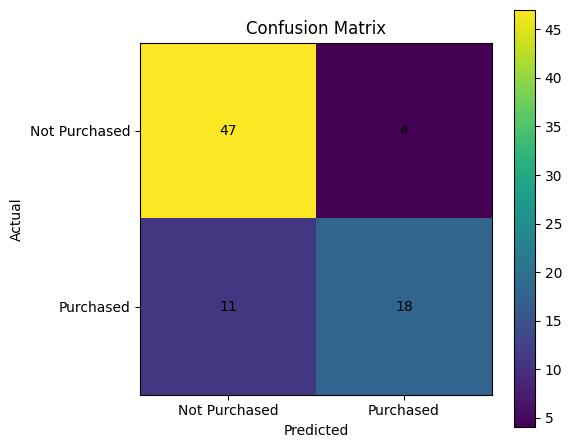

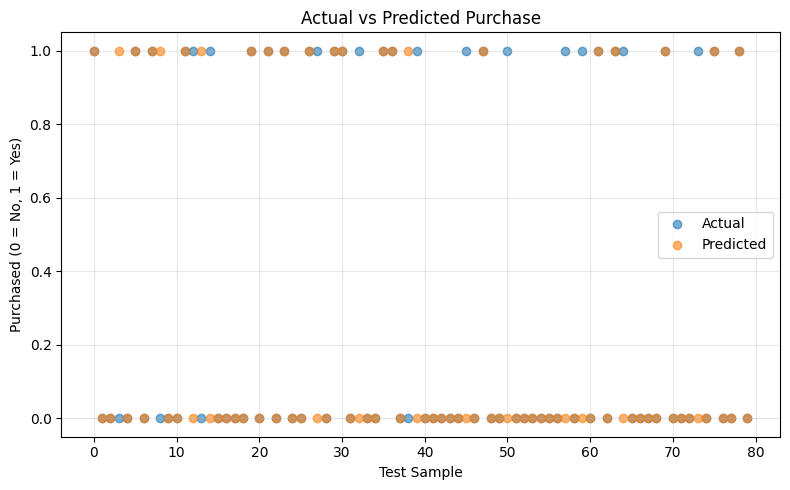



SAMPLE PREDICTIONS
    Actual  Gradient Descent  Sklearn
0        1                 1        1
1        0                 0        0
2        0                 0        0
3        0                 1        1
4        0                 0        0
5        1                 1        1
6        0                 0        0
7        1                 1        1
8        0                 1        1
9        0                 0        0
10       0                 0        0
11       1                 1        1
12       1                 0        0
13       0                 1        1
14       1                 0        0


FINAL SUMMARY

Total samples : 400
Training samples : 320
Testing samples : 80

Gradient Descent Accuracy : 81.25%
Sklearn Accuracy : 80.00%

Program completed successfully!


In [ ]:
# ============================================================
# LOGISTIC REGRESSION USING GRADIENT DESCENT
# Social Network Ads Dataset
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import zipfile
import os
import shutil

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression


# ============================================================
# 2. UPLOAD ZIP FILE
# ============================================================

print("Please upload the ZIP file.")

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]

print("\nUploaded file:")
print(zip_filename)


# ============================================================
# 3. CREATE EXTRACTION FOLDER
# ============================================================

# IMPORTANT:
# This must be a folder, NOT the ZIP filename.

extract_path = "/content/social_network_dataset"


# If folder already exists, remove it
if os.path.exists(extract_path):

    shutil.rmtree(
        extract_path
    )


# Create a fresh folder
os.makedirs(
    extract_path
)


# ============================================================
# 4. EXTRACT ZIP FILE
# ============================================================

with zipfile.ZipFile(
    zip_filename,
    "r"
) as zip_ref:

    zip_ref.extractall(
        extract_path
    )


print("\nZIP file extracted successfully!")


# ============================================================
# 5. FIND CSV FILE
# ============================================================

csv_file = None


for root, dirs, files_list in os.walk(
    extract_path
):

    for file in files_list:

        if file.lower() == "social_network_ads.csv":

            csv_file = os.path.join(
                root,
                file
            )


# Check if CSV was found

if csv_file is None:

    raise FileNotFoundError(
        "Social_Network_Ads.csv was not found "
        "inside the ZIP file."
    )


print("\nCSV file found:")
print(csv_file)


# ============================================================
# 6. LOAD DATASET
# ============================================================

df = pd.read_csv(
    csv_file
)


print("\nDataset loaded successfully!")


print(
    "Dataset shape:",
    df.shape
)


# ============================================================
# 7. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
)


print("\nColumn names:")

print(
    df.columns.tolist()
)


# ============================================================
# 8. DISPLAY FIRST 5 ROWS
# ============================================================

print("\nFirst 5 rows:")

print(
    df.head()
)


# ============================================================
# 9. CHECK MISSING VALUES
# ============================================================

print("\nMissing values:")

print(
    df.isnull().sum()
)


# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)


df["EstimatedSalary"] = (
    df["EstimatedSalary"]
    .fillna(
        df["EstimatedSalary"].median()
    )
)


# ============================================================
# 11. CONVERT GENDER TO NUMERICAL
# ============================================================

# Male = 1
# Female = 0

df["Gender"] = df["Gender"].map({

    "Male": 1,

    "Female": 0

})


# Check conversion

if df["Gender"].isnull().any():

    raise ValueError(
        "Gender contains unexpected values."
    )


# ============================================================
# 12. DEFINE FEATURES
# ============================================================

feature_columns = [

    "Gender",

    "Age",

    "EstimatedSalary"

]


# Target column

target_column = "Purchased"


# ============================================================
# 13. CREATE X AND y
# ============================================================

X = df[
    feature_columns
].values


y = df[
    target_column
].values.reshape(
    -1,
    1
)


print("\nFeatures:")

print(
    feature_columns
)


print(
    "\nTarget:",
    target_column
)


print(
    "\nX shape:",
    X.shape
)


print(
    "y shape:",
    y.shape
)


# ============================================================
# 14. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


print(
    "\nTraining samples:",
    X_train.shape[0]
)


print(
    "Testing samples:",
    X_test.shape[0]
)


# ============================================================
# 15. FEATURE SCALING
# ============================================================

scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)


# ============================================================
# 16. ADD BIAS COLUMN
# ============================================================

X_train_b = np.c_[

    np.ones(
        (X_train.shape[0], 1)
    ),

    X_train

]


X_test_b = np.c_[

    np.ones(
        (X_test.shape[0], 1)
    ),

    X_test

]


# ============================================================
# 17. SIGMOID FUNCTION
# ============================================================

def sigmoid(z):

    z = np.clip(
        z,
        -500,
        500
    )

    return 1 / (
        1 + np.exp(-z)
    )


# ============================================================
# 18. GRADIENT DESCENT FUNCTION
# ============================================================

def gradient_descent(
    X,
    y,
    lr=0.01,
    n_iters=5000
):

    # Number of samples

    m = X.shape[0]


    # Number of parameters

    n = X.shape[1]


    # Initialize theta

    theta = np.zeros(
        (n, 1)
    )


    # Store loss values

    losses = []


    # ========================================================
    # Gradient Descent Loop
    # ========================================================

    for i in range(
        n_iters
    ):


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        z = X @ theta


        # ----------------------------------------------------
        # Probability
        # ----------------------------------------------------

        y_prob = sigmoid(
            z
        )


        # ----------------------------------------------------
        # Error
        # ----------------------------------------------------

        error = y_prob - y


        # ----------------------------------------------------
        # Binary Cross Entropy Loss
        # ----------------------------------------------------

        epsilon = 1e-15


        y_prob_clipped = np.clip(

            y_prob,

            epsilon,

            1 - epsilon

        )


        loss = -(
            1 / m
        ) * np.sum(

            y * np.log(
                y_prob_clipped
            )

            +

            (1 - y) * np.log(
                1 - y_prob_clipped
            )

        )


        losses.append(
            loss
        )


        # ----------------------------------------------------
        # Gradient
        # ----------------------------------------------------

        gradient = (
            1 / m
        ) * (
            X.T @ error
        )


        # ----------------------------------------------------
        # Update theta
        # ----------------------------------------------------

        theta = (

            theta

            - lr * gradient

        )


        # ----------------------------------------------------
        # Print loss
        # ----------------------------------------------------

        if i % 500 == 0:

            print(
                f"Iteration {i:4d} | "
                f"Loss: {loss:.6f}"
            )


    return theta, losses


# ============================================================
# 19. RUN GRADIENT DESCENT
# ============================================================

print("\n")

print("=" * 60)

print(
    "RUNNING GRADIENT DESCENT"
)

print("=" * 60)


theta, losses = gradient_descent(

    X_train_b,

    y_train,

    lr=0.01,

    n_iters=5000

)


# ============================================================
# 20. MAKE PREDICTIONS
# ============================================================

test_probabilities = sigmoid(

    X_test_b @ theta

)


# Convert probabilities to 0 or 1

y_pred = (

    test_probabilities >= 0.5

).astype(int)


# ============================================================
# 21. CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(

    y_test,

    y_pred

)


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred

)


# ============================================================
# 23. DISPLAY GRADIENT DESCENT RESULTS
# ============================================================

print("\n")

print("=" * 60)

print(
    "GRADIENT DESCENT RESULTS"
)

print("=" * 60)


print("\nFinal weights:")

print(
    theta.ravel()
)


print(
    f"\nTest Accuracy : "
    f"{accuracy * 100:.2f}%"
)


print("\nConfusion Matrix:")

print(
    cm
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 24. SKLEARN LOGISTIC REGRESSION
# ============================================================

print("\n")

print("=" * 60)

print(
    "SKLEARN LOGISTIC REGRESSION"
)

print("=" * 60)


sk_model = LogisticRegression(

    random_state=42

)


sk_model.fit(

    X_train,

    y_train.ravel()

)


# ============================================================
# 25. SKLEARN PREDICTION
# ============================================================

sk_pred = sk_model.predict(

    X_test

)


# ============================================================
# 26. SKLEARN ACCURACY
# ============================================================

sk_accuracy = accuracy_score(

    y_test,

    sk_pred

)


# ============================================================
# 27. SKLEARN CONFUSION MATRIX
# ============================================================

sk_cm = confusion_matrix(

    y_test,

    sk_pred

)


# ============================================================
# 28. DISPLAY SKLEARN RESULTS
# ============================================================

print(
    f"\nSklearn Accuracy : "
    f"{sk_accuracy * 100:.2f}%"
)


print("\nSklearn Confusion Matrix:")

print(
    sk_cm
)


print("\nSklearn Classification Report:")

print(
    classification_report(
        y_test,
        sk_pred
    )
)


# ============================================================
# 29. MODEL COMPARISON
# ============================================================

print("\n")

print("=" * 60)

print(
    "MODEL COMPARISON"
)

print("=" * 60)


print(
    f"\nGradient Descent Accuracy : "
    f"{accuracy * 100:.2f}%"
)


print(
    f"Sklearn Accuracy          : "
    f"{sk_accuracy * 100:.2f}%"
)


# ============================================================
# 30. LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    range(len(losses)),

    losses,

    color="steelblue"

)


plt.title(
    "Logistic Regression: "
    "Loss vs Iterations"
)


plt.xlabel(
    "Iteration"
)


plt.ylabel(
    "Binary Cross-Entropy Loss"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "/content/logistic_loss_curve.png",
    dpi=150
)


plt.show()


# ============================================================
# 31. CONFUSION MATRIX GRAPH
# ============================================================

plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(
    "Confusion Matrix"
)


plt.colorbar()


plt.xticks(
    [0, 1],
    [
        "Not Purchased",
        "Purchased"
    ]
)


plt.yticks(
    [0, 1],
    [
        "Not Purchased",
        "Purchased"
    ]
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


# Display values

for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"

        )


plt.tight_layout()


plt.savefig(
    "/content/confusion_matrix.png",
    dpi=150
)


plt.show()


# ============================================================
# 32. ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.scatter(

    range(len(y_test)),

    y_test.ravel(),

    label="Actual",

    alpha=0.6

)


plt.scatter(

    range(len(y_pred)),

    y_pred.ravel(),

    label="Predicted",

    alpha=0.6

)


plt.title(
    "Actual vs Predicted Purchase"
)


plt.xlabel(
    "Test Sample"
)


plt.ylabel(
    "Purchased (0 = No, 1 = Yes)"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "/content/actual_vs_predicted.png",
    dpi=150
)


plt.show()


# ============================================================
# 33. SAMPLE PREDICTIONS
# ============================================================

prediction_df = pd.DataFrame({

    "Actual":

        y_test.ravel(),

    "Gradient Descent":

        y_pred.ravel(),

    "Sklearn":

        sk_pred.ravel()

})


print("\n")

print("=" * 60)

print(
    "SAMPLE PREDICTIONS"
)

print("=" * 60)


print(
    prediction_df.head(15)
)


# ============================================================
# 34. FINAL SUMMARY
# ============================================================

print("\n")

print("=" * 60)

print(
    "FINAL SUMMARY"
)

print("=" * 60)


print(
    f"\nTotal samples : "
    f"{len(df)}"
)


print(
    f"Training samples : "
    f"{len(X_train)}"
)


print(
    f"Testing samples : "
    f"{len(X_test)}"
)


print(
    f"\nGradient Descent Accuracy : "
    f"{accuracy * 100:.2f}%"
)


print(
    f"Sklearn Accuracy : "
    f"{sk_accuracy * 100:.2f}%"
)


print(
    "\nProgram completed successfully!"
)